# Vocabulaire + Bag of Words + SVM

Pipeline complet: Extraction ORB → Vocabulaire K-Means → Histogrammes BOW → Classification SVM

## Phase 1 : Création du Vocabulaire

In [1]:
import cv2
import numpy as np
import os
from sklearn.cluster import KMeans
from tqdm import tqdm

NBR_CLUSTER = 200  # Nombre de clusters pour K-Means

train_path = "dataset/training_set"
image_paths = []

# Pour les chiens
dogs_path = os.path.join(train_path, "dogs")
for filename in os.listdir(dogs_path):
    image_paths.append(os.path.join(dogs_path, filename))

    # Pour les chats
cats_path = os.path.join(train_path, "cats")
for filename in os.listdir(cats_path):
    image_paths.append(os.path.join(cats_path, filename))

print(f"Nombre total d'images : {len(image_paths)}")

orb = cv2.ORB_create()

des_list = []

print("Extraction des descripteurs...")
for image_path in tqdm(image_paths, desc="Images traitées"):
    # Charger l'image
    img = cv2.imread(image_path)
    
    # Vérifier que l'image est chargée
    if img is None:
        continue
    
    # Détecter keypoints
    kp = orb.detect(img, None)
    
    # Calculer descripteurs
    kp, des = orb.compute(img, kp)
    
    # Ajouter les descripteurs à la liste
    if des is not None:
        des_list.append(des)

print(f"Nombre d'images traitées : {len(des_list)}")

# Empiler tous les descripteurs verticalement
descriptors = des_list[0]  # Commencer avec les descripteurs de la 1ère image

for des in des_list[1:]:
    descriptors = np.vstack((descriptors, des))

descriptors_float = descriptors.astype(float)

k = NBR_CLUSTER  # Nombre de clusters

print("\nCréation du vocabulaire avec K-Means...")
kmeans_model = KMeans(n_clusters=k, verbose=1, n_init=10)
kmeans_model.fit(descriptors_float)
vocabulary = kmeans_model.cluster_centers_

print(f"\nVocabulaire créé ! Forme : {vocabulary.shape}")

# Optionnel car on sais jamais si on va en avoir besoin plus tard
np.save("outputs/vocabulary.npy", vocabulary)
print("Vocabulaire sauvegardé dans outputs/vocabulary.npy")

Nombre total d'images : 8000
Extraction des descripteurs...


Images traitées: 100%|██████████| 8000/8000 [00:23<00:00, 334.36it/s]


Nombre d'images traitées : 7987

Création du vocabulaire avec K-Means...
Initialization complete
Iteration 0, inertia 458561975798.0.
Iteration 1, inertia 356678429116.25885.
Iteration 2, inertia 350048621893.816.
Iteration 3, inertia 347347133443.1042.
Iteration 4, inertia 345809675303.11847.
Iteration 5, inertia 344793850267.15027.
Iteration 6, inertia 344066229942.10266.
Iteration 7, inertia 343514672000.2957.
Iteration 8, inertia 343079669048.41016.
Iteration 9, inertia 342727376681.6179.
Iteration 10, inertia 342433691402.5864.
Iteration 11, inertia 342187344786.91614.
Iteration 12, inertia 341978056701.5177.
Iteration 13, inertia 341798833738.9101.
Iteration 14, inertia 341643559138.4465.
Iteration 15, inertia 341507335119.1796.
Iteration 16, inertia 341387109752.57117.
Iteration 17, inertia 341280397336.8144.
Iteration 18, inertia 341184680374.7595.
Iteration 19, inertia 341097373634.746.
Iteration 20, inertia 341017007073.5934.
Iteration 21, inertia 340943824242.6885.
Iteration

## Phase 2 : Transformation Bag of Words

In [2]:
from scipy.cluster.vq import vq
import random

NBR_WORDS = 200  # Nombre de mots visuels

# Charger le vocabulaire
vocabulary = np.load("outputs/vocabulary.npy")
print(f"Vocabulaire chargé : {vocabulary.shape}")

k = NBR_WORDS  # Nombre de mots visuels

# TRAINING SET
train_path = "dataset/training_set"

image_paths_train = []
labels_train = []

# Chiens (classe 0)
for filename in os.listdir(os.path.join(train_path, "dogs")):
    image_paths_train.append(os.path.join(train_path, "dogs", filename))
    labels_train.append(0)

# Chats (classe 1)
for filename in os.listdir(os.path.join(train_path, "cats")):
    image_paths_train.append(os.path.join(train_path, "cats", filename))
    labels_train.append(1)

# TEST SET
test_path = "dataset/test_set"

image_paths_test = []
labels_test = []

# Chiens
for filename in os.listdir(os.path.join(test_path, "dogs")):
    image_paths_test.append(os.path.join(test_path, "dogs", filename))
    labels_test.append(0)

# Chats
for filename in os.listdir(os.path.join(test_path, "cats")):
    image_paths_test.append(os.path.join(test_path, "cats", filename))
    labels_test.append(1)

print(f"\n=== TRAINING SET ===")
print(f"Nombre total d'images : {len(image_paths_train)}")
print(f"Chiens (0) : {labels_train.count(0)}")
print(f"Chats (1) : {labels_train.count(1)}")

print(f"\n=== TEST SET ===")
print(f"Nombre total d'images : {len(image_paths_test)}")
print(f"Chiens (0) : {labels_test.count(0)}")
print(f"Chats (1) : {labels_test.count(1)}")

def image_to_histogram(image_path, orb, vocabulary, k):

    # Charger l'image
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Détecter keypoints
    kp = orb.detect(img, None)

    # Calculer descripteurs
    kp, des = orb.compute(img, kp)

    # Si l'image n'a pas de descripteurs, retourner un vecteur de zéros
    if des is None:
        return np.zeros(k)
    
    # Assigner chaque descripteur au mot visuel le plus proche
    words, distances = vq(des, vocabulary)

    # Créer l'histogramme (compter les occurrences de chaque mot)
    histogram = np.zeros(k)
    for word in words:
        histogram[word] += 1
    
    return histogram

orb = cv2.ORB_create()

print("\n--- Transformation du TRAINING SET ---")
X_train = []  # X_train = histogrammes des images d'entraînement (features)
y_train = []  # y_train = labels des images (0=chien, 1=chat)

for i, (image_path, label) in enumerate(zip(image_paths_train, labels_train)):
    # Afficher la progression tous les 500 images
    if i % 500 == 0:
        print(f"Progression : {i}/{len(image_paths_train)}")
    
    # Transformer l'image en histogramme
    histogram = image_to_histogram(image_path, orb, vocabulary, k)
    
    # Si l'image a pu être traitée
    if histogram is not None:
        X_train.append(histogram)
        y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")

print("\n--- Transformation du TEST SET ---")
X_test = []
y_test = []

for i, (image_path, label) in enumerate(zip(image_paths_test, labels_test)):
    if i % 100 == 0:
        print(f"Progression : {i}/{len(image_paths_test)}")
    
    histogram = image_to_histogram(image_path, orb, vocabulary, k)
    
    if histogram is not None:
        X_test.append(histogram)
        y_test.append(label)

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")


print("\n--- Sauvegarde des données ---")

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

print("✓ X_train.npy sauvegardé")
print("✓ y_train.npy sauvegardé")
print("✓ X_test.npy sauvegardé")
print("✓ y_test.npy sauvegardé")

print("\n=== PHASE 3 TERMINÉE ===")
print(f"X_train : {X_train.shape}")
print(f"X_test : {X_test.shape}")

Vocabulaire chargé : (200, 32)

=== TRAINING SET ===
Nombre total d'images : 8000
Chiens (0) : 4000
Chats (1) : 4000

=== TEST SET ===
Nombre total d'images : 2000
Chiens (0) : 1000
Chats (1) : 1000

--- Transformation du TRAINING SET ---
Progression : 0/8000
Progression : 500/8000
Progression : 1000/8000
Progression : 1500/8000
Progression : 2000/8000
Progression : 2500/8000
Progression : 3000/8000
Progression : 3500/8000
Progression : 4000/8000
Progression : 4500/8000
Progression : 5000/8000
Progression : 5500/8000
Progression : 6000/8000
Progression : 6500/8000
Progression : 7000/8000
Progression : 7500/8000
X_train shape : (8000, 200)
y_train shape : (8000,)

--- Transformation du TEST SET ---
Progression : 0/2000
Progression : 100/2000
Progression : 200/2000
Progression : 300/2000
Progression : 400/2000
Progression : 500/2000
Progression : 600/2000
Progression : 700/2000
Progression : 800/2000
Progression : 900/2000
Progression : 1000/2000
Progression : 1100/2000
Progression : 120

## Phase 3 : Classification SVM

Chargement des données...
X_train shape : (8000, 200)
y_train shape : (8000,)
X_test shape : (2000, 200)
y_test shape : (2000,)

Normalisation des données...
Normalisation terminée.

Entraînement du modèle SVM...
Entraînement terminé.

Prédictions sur le test set...
Prédictions terminées.

Évaluation du modèle...
Accuracy : 0.7100
Matrice de confusion :
[[737 263]
 [317 683]]


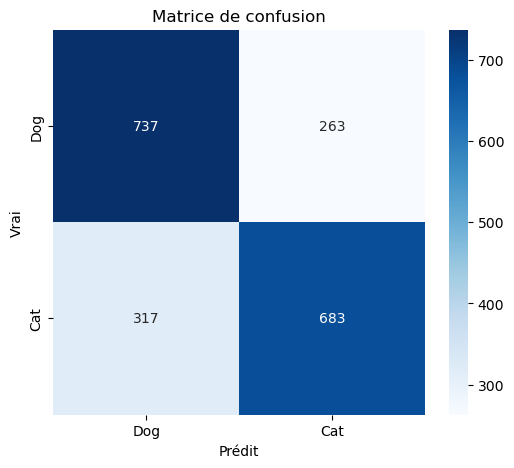

In [3]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ===== Étape 1 : Charger les données =====
print("Chargement des données...")

X_train = np.load("outputs/X_train.npy")
y_train = np.load("outputs/y_train.npy")
X_test = np.load("outputs/X_test.npy")
y_test = np.load("outputs/y_test.npy")

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")

# ===== Étape 2 : Normaliser =====
print("\nNormalisation des données...")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalisation terminée.")

# ===== Étape 3 : Entraîner le SVM =====
print("\nEntraînement du modèle SVM...")

model = SVC(kernel="rbf", C=1.0, gamma="scale")
model.fit(X_train, y_train)

print("Entraînement terminé.")

# ===== Étape 4 : Prédictions =====
print("\nPrédictions sur le test set...")

y_pred = model.predict(X_test)

print("Prédictions terminées.")

# ===== Étape 5 : Évaluation =====
print("\nÉvaluation du modèle...")

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

# Affichage graphique
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dog", "Cat"],
            yticklabels=["Dog", "Cat"])
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.title("Matrice de confusion")
plt.show()

# ===== Étape 6 : Sauvegarde du modèle =====
#joblib.dump(model, "svm_model.pkl")
#print("Modèle sauvegardé : svm_model.pkl")